# Orphan classifier

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import joblib

# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html#sklearn.ensemble.GradientBoostingClassifier.fit
# https://scikit-learn.org/stable/modules/ensemble.html#gradient-boosting
from sklearn import preprocessing
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.inspection import permutation_importance
from matplotlib.lines import Line2D

In [3]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

## Open features file

In [4]:
df_features = pd.read_pickle('../data/orphans_elasticc_features.pkl')
df_features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 697774 entries, 0 to 695358
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   grb_time         2415 non-null    object 
 1   duration         697774 non-null  float64
 2   increase_rate    697774 non-null  float64
 3   decrease_rate    697774 non-null  float64
 4   decrease_rate_1  697774 non-null  float64
 5   decrease_rate_3  697774 non-null  float64
 6   u-g              296085 non-null  float64
 7   g-r              373330 non-null  float64
 8   r-i              544325 non-null  float64
 9   i-z              510440 non-null  float64
 10  z-Y              446383 non-null  float64
 11  A                697774 non-null  float64
 12  B                697774 non-null  float64
 13  C                697774 non-null  float64
 14  D                697774 non-null  float64
 15  A/B              697774 non-null  float64
 16  chi2             697575 non-null  float64
 

In [5]:
# replace not valid values
df_features.replace([np.inf, -np.inf], 1000, inplace=True)

In [6]:
df_features.fillna(0, inplace=True)
df_features.head()

,grb_time,duration,increase_rate,decrease_rate,decrease_rate_1,decrease_rate_3,u-g,g-r,r-i,i-z,z-Y,A,B,C,D,A/B,chi2,type,alertId
0,2028-01-27T21:02:31.349,0.000000,0.00000,0.047314,0.085273,0.016193,0.442054,-0.852039,0.113965,0.090843,0.087507,0.009522,28.352623,-4.322088,0.028148,0.000336,0.000130,orphans,0.0
1,2027-01-23T22:00:36.407,0.000000,0.00000,0.019702,0.028916,0.010698,0.000000,0.257427,0.143853,0.147066,0.166562,0.020842,23.551006,-1.055726,1.499994,0.000885,0.248048,orphans,0.0
2,2030-06-10T21:00:53.195,0.000000,0.00000,0.018271,0.028003,0.010916,-0.310239,0.122053,0.135443,0.070409,0.138542,0.011337,24.121623,-1.562848,0.041076,0.000470,0.004556,orphans,0.0
3,2029-11-18T15:33:08.925,4.044343,-0.31876,0.029625,0.053402,0.012030,1.110884,0.294058,0.154724,0.211315,-0.002052,0.032337,23.697549,2.797178,1.386193,0.001365,0.256146,orphans,0.0
4,2026-04-15T15:09:17.377,0.000239,0.00000,0.005472,0.006397,0.004494,0.000000,0.508994,0.229818,0.170728,0.135634,0.005531,25.958781,-0.229910,2.765273,0.000213,0.004923,orphans,0.0


In [7]:
# keep only useful columns
df_features = df_features.drop(columns=['grb_time', 'alertId', 'decrease_rate', 'u-g', 'i-z', 'z-Y'])

## Divide events into training and testing data sets

In [8]:
# create a sub dataframe with just elasticc data
df_el = df_features[df_features['type']=='elasticc']
df_el.info()

<class 'pandas.core.frame.DataFrame'>
Index: 695359 entries, 0 to 695358
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   duration         695359 non-null  float64
 1   increase_rate    695359 non-null  float64
 2   decrease_rate_1  695359 non-null  float64
 3   decrease_rate_3  695359 non-null  float64
 4   g-r              695359 non-null  float64
 5   r-i              695359 non-null  float64
 6   A                695359 non-null  float64
 7   B                695359 non-null  float64
 8   C                695359 non-null  float64
 9   D                695359 non-null  float64
 10  A/B              695359 non-null  float64
 11  chi2             695359 non-null  float64
 12  type             695359 non-null  object 
dtypes: float64(12), object(1)
memory usage: 74.3+ MB


In [9]:
# create a sub dataframe with just orphans data
df_oa = df_features[df_features['type']=='orphans']
df_oa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2415 entries, 0 to 2414
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   duration         2415 non-null   float64
 1   increase_rate    2415 non-null   float64
 2   decrease_rate_1  2415 non-null   float64
 3   decrease_rate_3  2415 non-null   float64
 4   g-r              2415 non-null   float64
 5   r-i              2415 non-null   float64
 6   A                2415 non-null   float64
 7   B                2415 non-null   float64
 8   C                2415 non-null   float64
 9   D                2415 non-null   float64
 10  A/B              2415 non-null   float64
 11  chi2             2415 non-null   float64
 12  type             2415 non-null   object 
dtypes: float64(12), object(1)
memory usage: 264.1+ KB


In [10]:
# creating training and testing samples of elasticc data
df_train_el = df_el[:10000].drop(columns=['type'])
df_test_el = df_el[10000:].drop(columns=['type'])
df_train_el.info()
y_train_el = df_el[:10000]['type']
y_test_el = df_el[10000:]['type']
y_test_el.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   duration         10000 non-null  float64
 1   increase_rate    10000 non-null  float64
 2   decrease_rate_1  10000 non-null  float64
 3   decrease_rate_3  10000 non-null  float64
 4   g-r              10000 non-null  float64
 5   r-i              10000 non-null  float64
 6   A                10000 non-null  float64
 7   B                10000 non-null  float64
 8   C                10000 non-null  float64
 9   D                10000 non-null  float64
 10  A/B              10000 non-null  float64
 11  chi2             10000 non-null  float64
dtypes: float64(12)
memory usage: 1015.6 KB
<class 'pandas.core.series.Series'>
Index: 685359 entries, 10000 to 695358
Series name: type
Non-Null Count   Dtype 
--------------   ----- 
685359 non-null  object
dtypes: object(1)
memory usage: 10.5+ MB


In [11]:
# creating training and testing samples of orphan afterglows
df_train_oa = df_oa[:500].drop(columns=['type'])
df_test_oa = df_oa[500:].drop(columns=['type'])
df_train_oa.info()
y_train_oa = df_oa[:500]['type']
y_test_oa = df_oa[500:]['type']
y_test_oa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   duration         500 non-null    float64
 1   increase_rate    500 non-null    float64
 2   decrease_rate_1  500 non-null    float64
 3   decrease_rate_3  500 non-null    float64
 4   g-r              500 non-null    float64
 5   r-i              500 non-null    float64
 6   A                500 non-null    float64
 7   B                500 non-null    float64
 8   C                500 non-null    float64
 9   D                500 non-null    float64
 10  A/B              500 non-null    float64
 11  chi2             500 non-null    float64
dtypes: float64(12)
memory usage: 50.8 KB
<class 'pandas.core.series.Series'>
Index: 1915 entries, 500 to 2414
Series name: type
Non-Null Count  Dtype 
--------------  ----- 
1915 non-null   object
dtypes: object(1)
memory usage: 29.9+ KB


In [12]:
# create training and testing samples
X_train = pd.concat([df_train_el, df_train_oa])
X_test = pd.concat([df_test_el, df_test_oa])
y_train = pd.concat([y_train_el, y_train_oa])
y_test = pd.concat([y_test_el, y_test_oa])

In [13]:
# normalise the features
X_train_norm = preprocessing.normalize(X_train, norm='max')
X_test_norm = preprocessing.normalize(X_test, norm='max')

In [14]:
clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                 max_depth=5, random_state=0).fit(X_train_norm, y_train)

In [15]:
clf.score(X_test_norm, y_test)

0.999483466565009

Text(0, 0.5, 'loss')

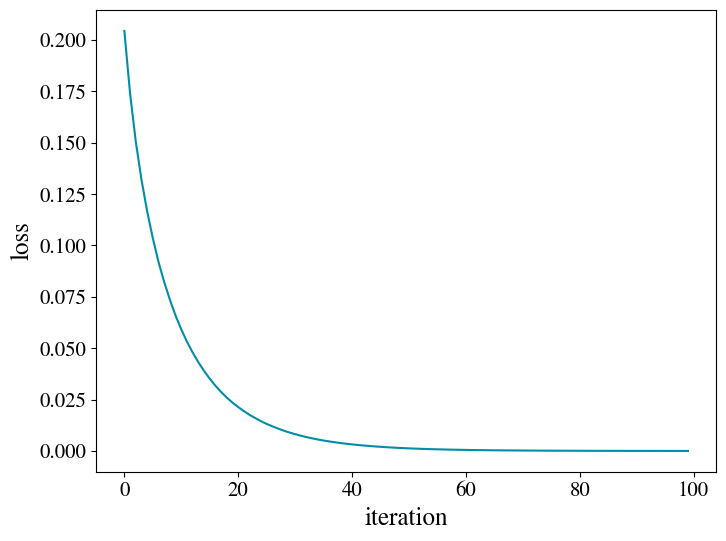

In [16]:
plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 15})

plt.plot(clf.train_score_, color='#008da7')
plt.xlabel('iteration', fontsize=18)
plt.ylabel('loss', fontsize=18)

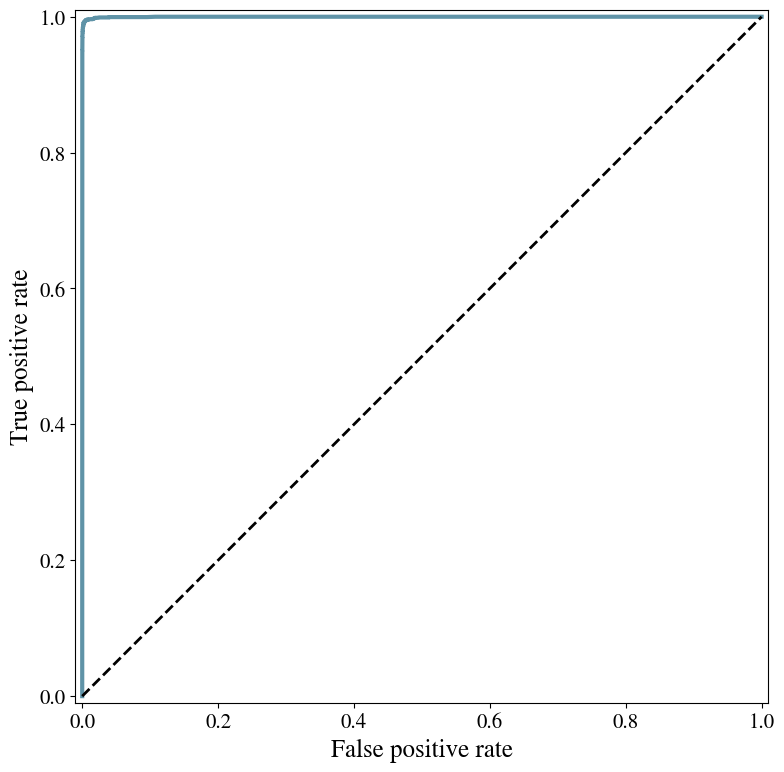

In [17]:
from sklearn.metrics import RocCurveDisplay

plt.rcParams.update({'font.size': 15})

x = np.linspace(0., 1., 100)
y = np.linspace(0., 1., 100)

fig, ax = plt.subplots(figsize=(9, 9))

RocCurveDisplay.from_estimator(clf, X_test_norm, y_test, ax=ax, color="#5f93a7", lw=3)
plt.plot(x, y, color='k', lw=2., ls='--', label='random')
ax.set_xlabel('False positive rate', fontsize=18)
ax.set_ylabel('True positive rate', fontsize=18)
#ax.set_xlim(-0.01, 0.2)
ax.legend_.remove()
#ax.set_ylim(0.95, 1.003)

#plt.savefig('../figures/roc_curve.pdf', transparent=True, bbox_inches='tight')

plt.show()

## Confusion matrix

In [18]:
y_pred = clf.predict(X_test)

/home/masson/anaconda3/envs/afterglowpy/lib/python3.12/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


In [19]:
threshold = 0.9999
y_pred_bool = np.array(clf.predict_proba(X_test_norm)[:, 1] >= threshold)

y_pred= []
for y in y_pred_bool:
    if y == True:
        y_pred.append('orphans')
    elif y == False:
        y_pred.append('elasticc')
    else:
        print(y)

In [20]:
proba=clf.predict_proba(X_test_norm)

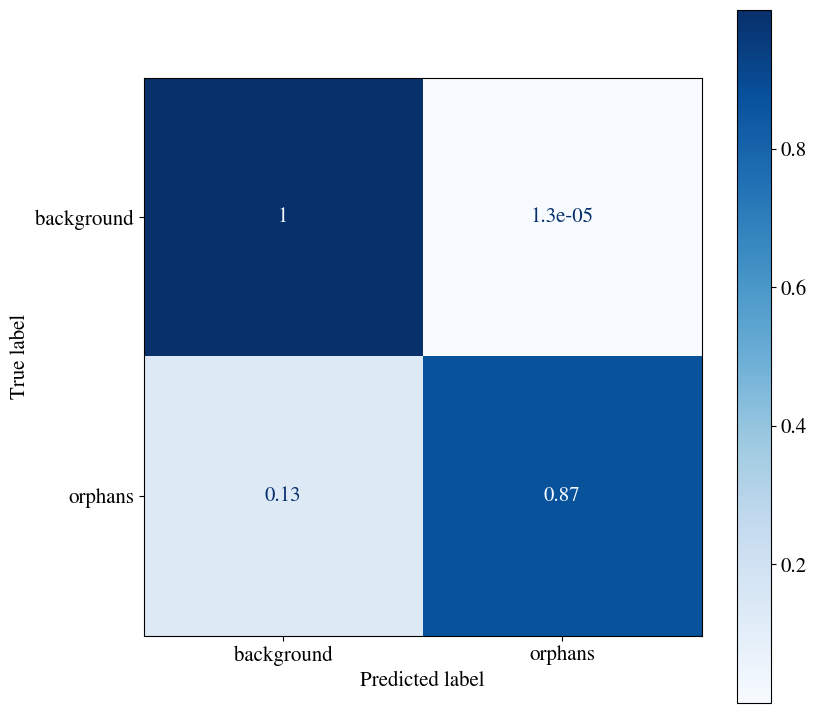

In [21]:
plt.rcParams["figure.figsize"] = [9, 9]
plt.rcParams["font.size"] = 15

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                              display_labels=['background', 'orphans'],
                                              cmap=plt.cm.Blues,
                                              normalize='true')

#plt.savefig('../figures/confusion_matrix_09999.pdf', transparent=True, bbox_inches='tight')

## Feature contribution

In [22]:
result = permutation_importance(clf, X_test_norm, y_test, n_repeats=10, random_state=0)

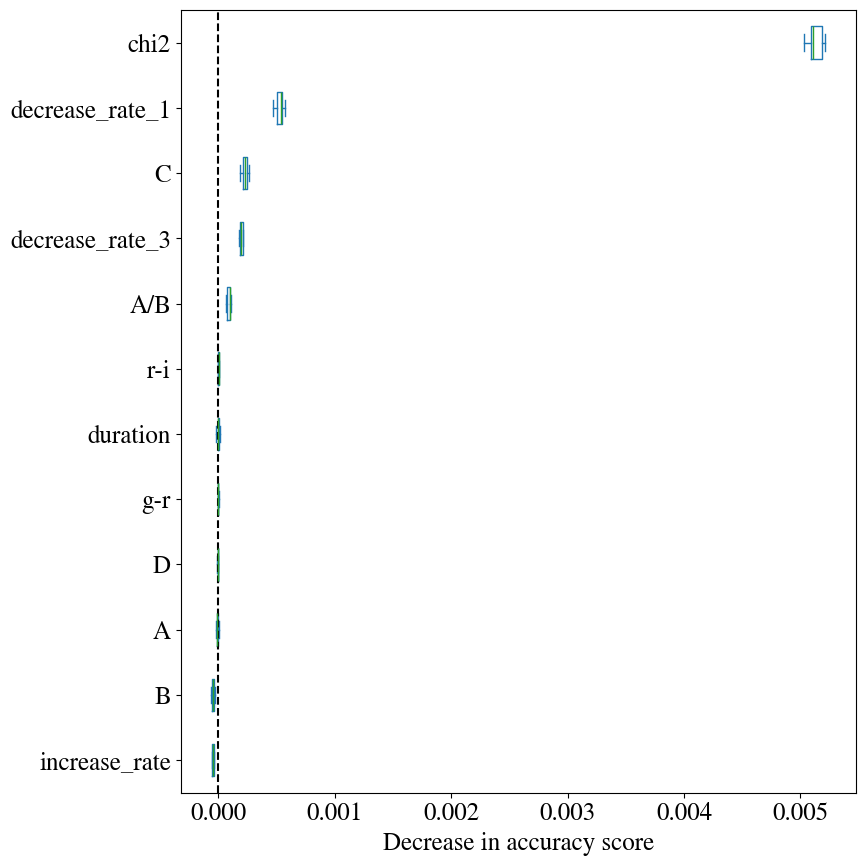

In [23]:
plt.rcParams.update({'font.size': 18})

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(result.importances[sorted_importances_idx].T, 
                           columns=X_test.columns[sorted_importances_idx])

fig, ax = plt.subplots(1,1,figsize=(9,9))
importances.plot.box(vert=False, ax=ax, whis=10)
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

#plt.savefig('../figures/features_importance.pdf', transparent=True, bbox_inches='tight')

plt.show()

## Events classified as orphan afterglows

In [24]:
df_elasticc_data = pd.read_pickle(f'../data/elasticc_no_periodic_events.pkl')

In [25]:
df_features = pd.read_pickle('../data/orphans_elasticc_features.pkl')

In [26]:
X_test_proba = X_test
X_test_proba['proba_orphan'] = proba[:,1]
X_test_proba['type'] = y_test

In [27]:
# keep only events classified as orphans with a proba > specified threshold
X_test_proba_orphan = X_test_proba[X_test_proba['proba_orphan'] > threshold]

In [28]:
len(X_test_proba_orphan[X_test_proba_orphan['type']=='elasticc'])

9

In [29]:
# create a DataFrame with only the background events that are classified as orphans
elasticc_classified_orphans = pd.merge(X_test_proba_orphan[X_test_proba_orphan['type']=='elasticc'], 
                                       df_features[df_features['type']=='elasticc'], on=['duration', 'increase_rate',
                                                                                         'decrease_rate_1', 'decrease_rate_3',
                                                                                         'g-r', 'r-i', 'A', 'B', 'C', 'D', 'chi2'], 
                                       suffixes=('', '_y'), how = 'left')

elasticc_classified_orphans = elasticc_classified_orphans.drop(columns=['grb_time', 'decrease_rate', 'u-g', 'i-z', 'z-Y', 'A/B_y', 'type_y'])

In [30]:
df_features[df_features['type']=='elasticc']

,grb_time,duration,increase_rate,decrease_rate,decrease_rate_1,decrease_rate_3,u-g,g-r,r-i,i-z,z-Y,A,B,C,D,A/B,chi2,type,alertId
0,NaN,12.0063,-0.009712,0.006043,0.000000,0.000000,1.662334,0.294448,-0.161946,-0.478214,NaN,0.013037,21.370721,1.321343,0.246719,0.000610,30.163250,elasticc,1.072650e+11
1,NaN,17.9709,0.000000,0.019886,0.005537,0.004732,2.301299,1.275123,0.504166,-0.006196,0.353124,0.027237,21.562929,-0.075280,2.999981,0.001263,64.421679,elasticc,1.262691e+11
2,NaN,10.0131,-0.014918,0.020222,0.006000,0.013380,0.812763,0.618943,0.144361,-0.026153,-0.019558,0.010250,20.872511,0.416916,2.935582,0.000491,59.410639,elasticc,4.121531e+10
3,NaN,0.0115,-0.005554,0.010894,0.000000,0.000000,1.007703,1.357699,0.311295,0.028638,0.075844,0.126158,21.568866,0.558124,2.999974,0.005849,40.517624,elasticc,3.863150e+10
4,NaN,0.0234,0.000000,0.088888,0.000000,0.000000,NaN,NaN,0.428431,NaN,NaN,0.509532,16.865246,6.808630,2.996054,0.030212,2.395484,elasticc,1.080764e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695354,NaN,9.1450,0.000000,0.044050,0.011905,0.039283,-1.442929,-0.051153,NaN,NaN,NaN,-0.189019,22.121261,-0.614820,2.999998,-0.008545,223.648199,elasticc,1.317575e+11
695355,NaN,9.8742,-0.011638,0.001732,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,-0.003424,20.737885,0.204668,2.997273,-0.000165,24.221001,elasticc,7.148774e+10
695356,NaN,6.0077,-0.046450,0.016607,0.011797,0.005583,NaN,NaN,-3.228164,2.713774,NaN,0.011446,21.686656,1.929502,0.623318,0.000528,14.264892,elasticc,9.971202e+10
695357,NaN,34.9518,-0.068334,0.016162,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,-0.029772,22.426863,-0.552712,0.113953,-0.001328,210.662104,elasticc,2.576146e+10


In [31]:
# get the alert Id of background events classified as orphans
alertId_elastorphan = []

for chi2 in elasticc_classified_orphans['chi2']:
    alertId = df_features[(df_features['type']=='elasticc') & (df_features['chi2']==chi2)]['alertId']
    alertId_elastorphan.append(int(alertId.values[0]))

In [32]:
# get the topic (aka their class: SN, KN, AGN...) of background events classified as orphans

topic_elastorphan = []

for i in alertId_elastorphan:
    topic = df_elasticc_data[df_elasticc_data['alertId']==i]['topic']
    topic_elastorphan.append(topic.values)

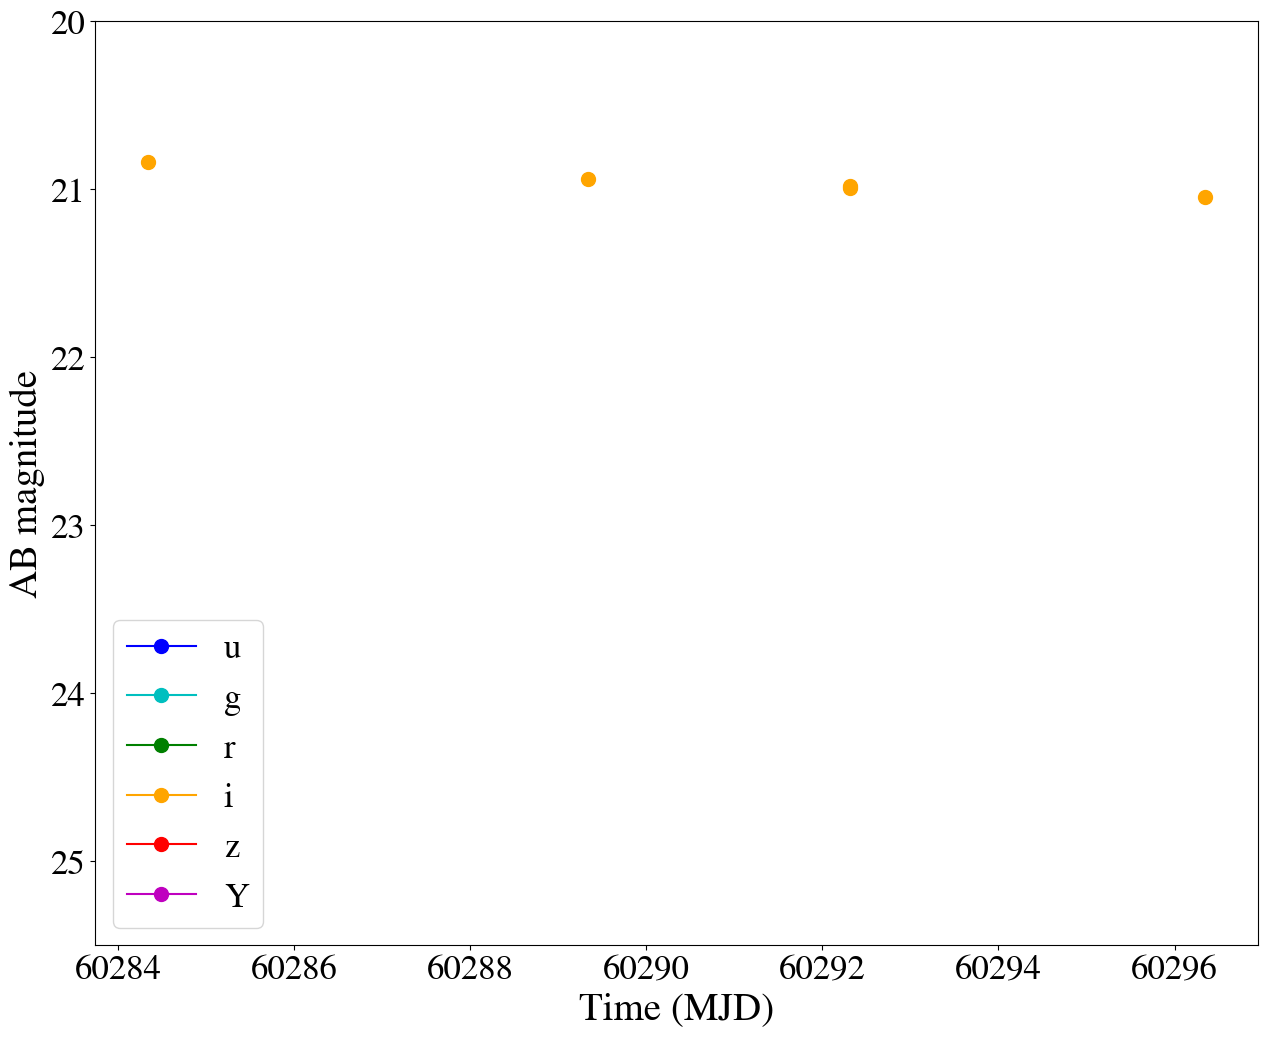

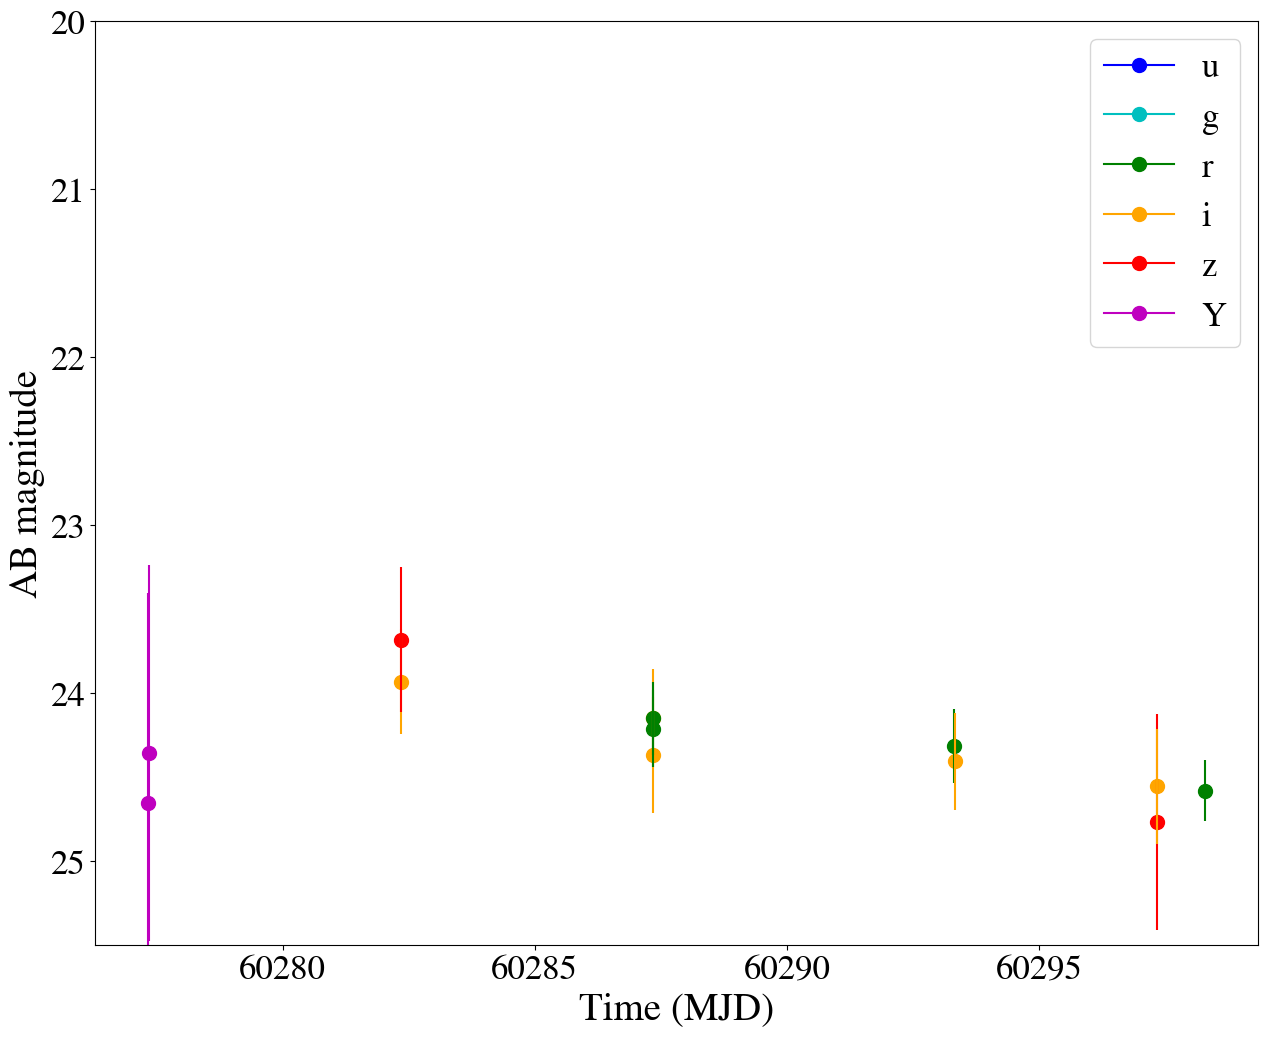

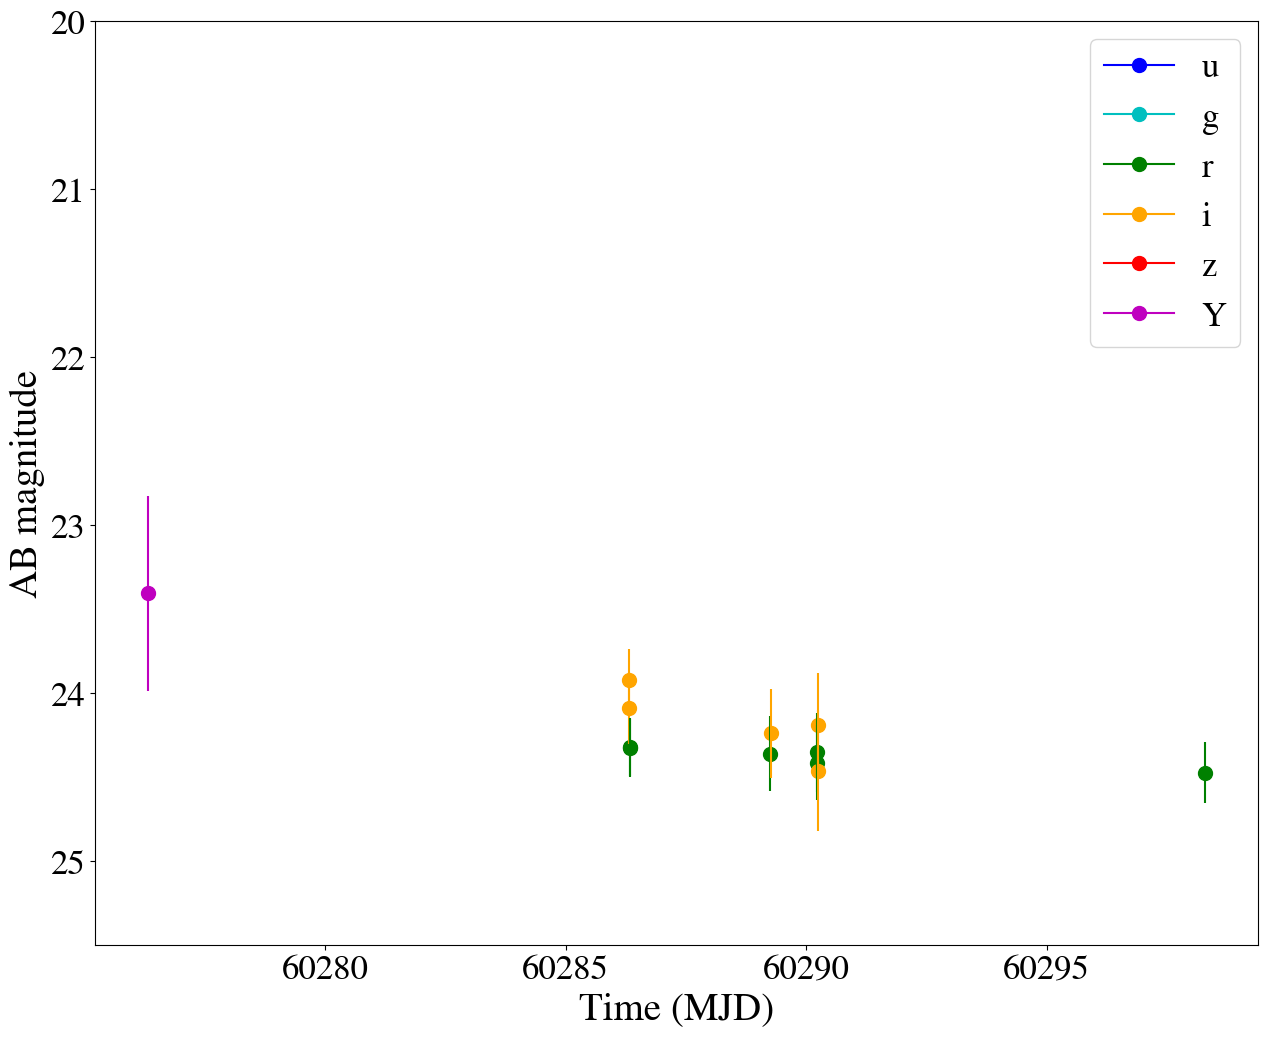

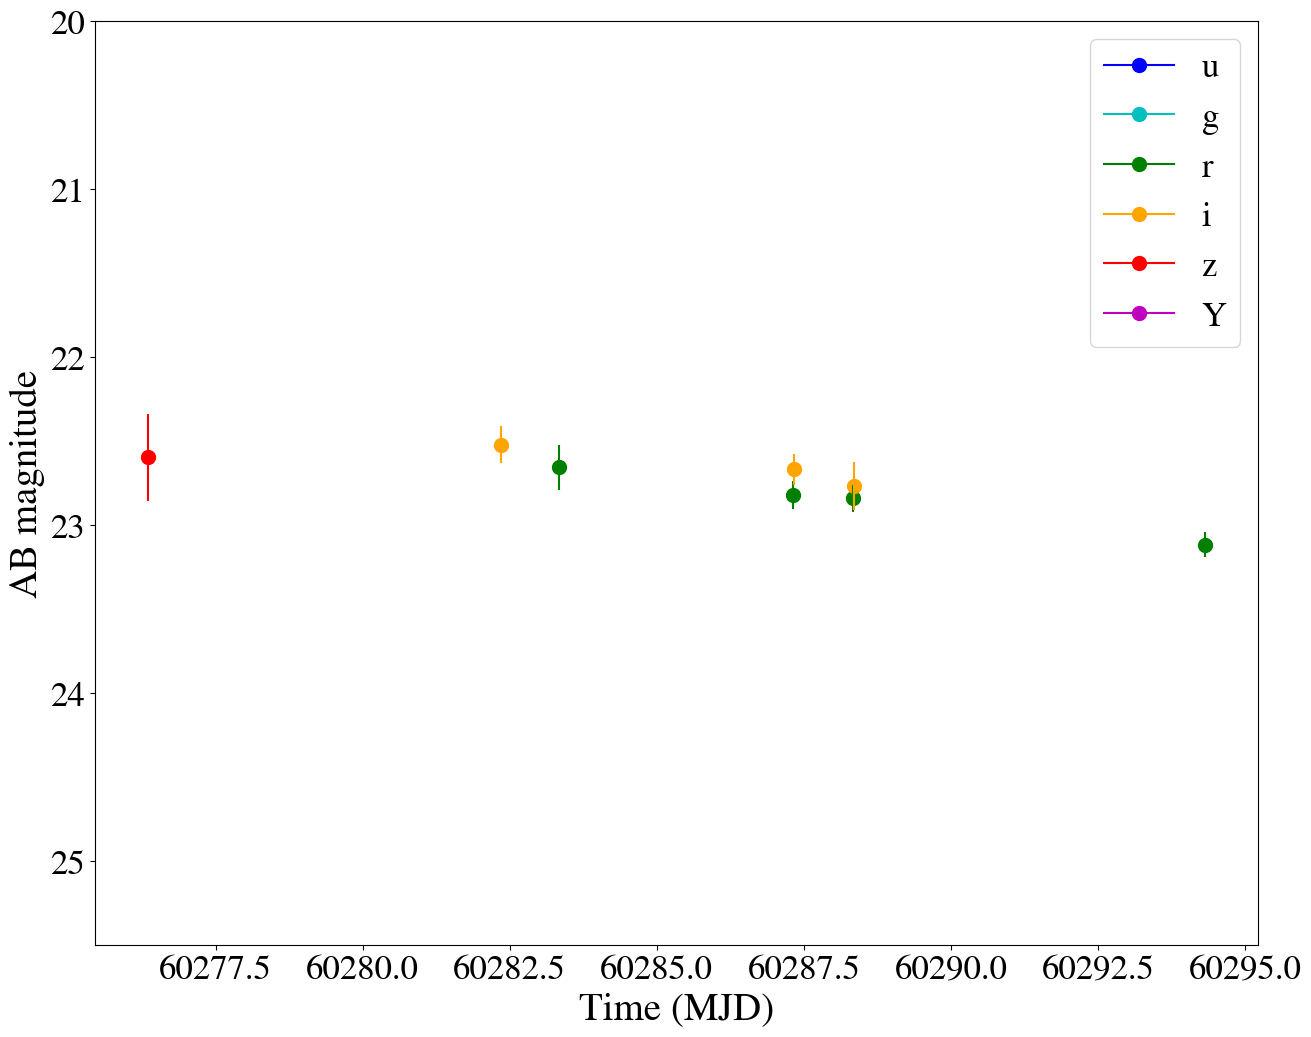

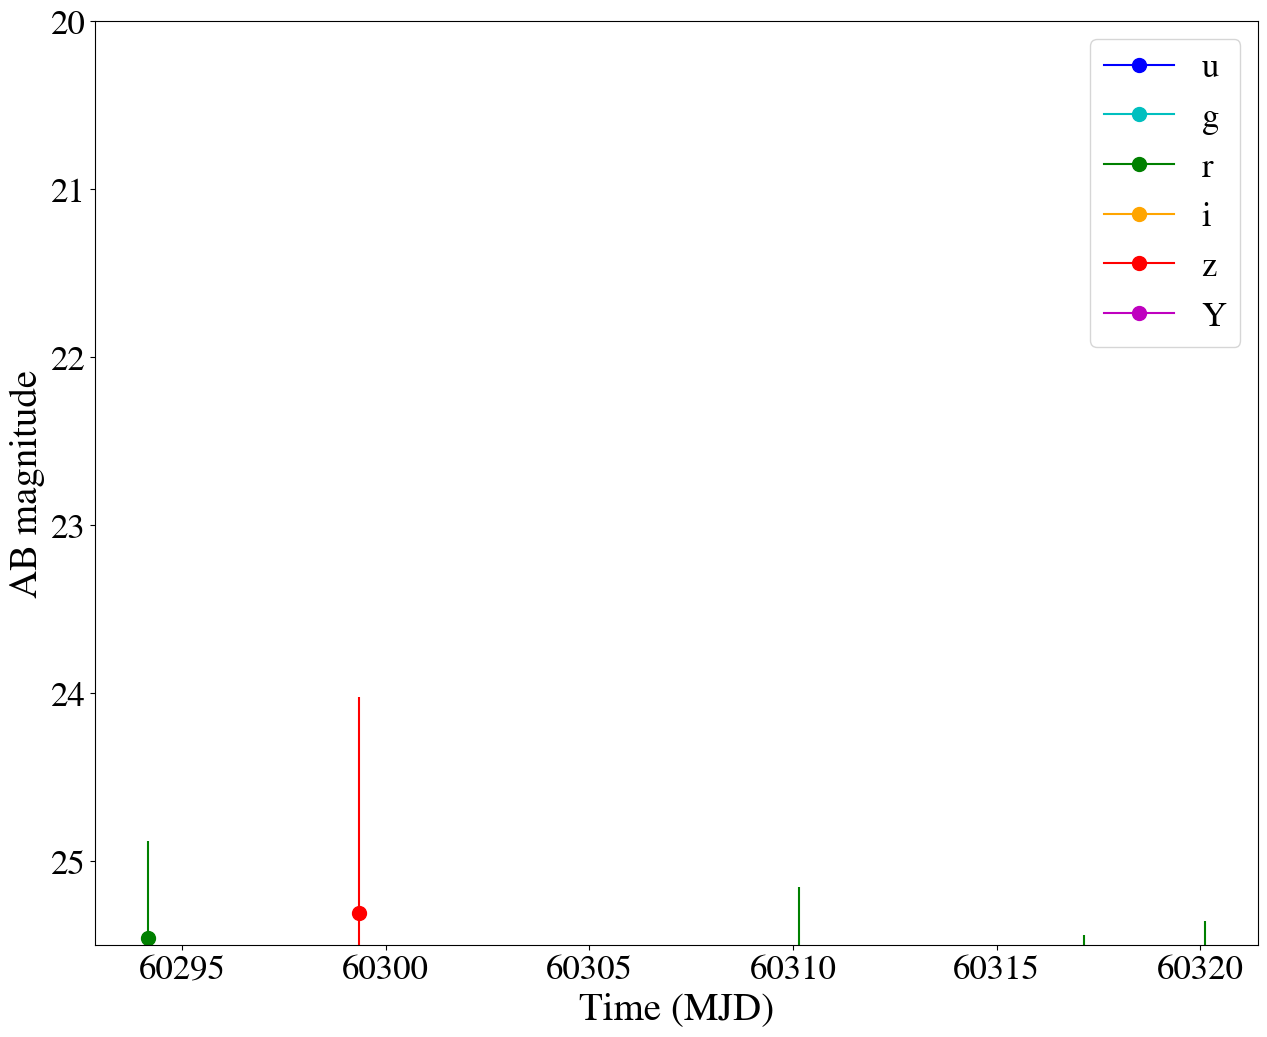

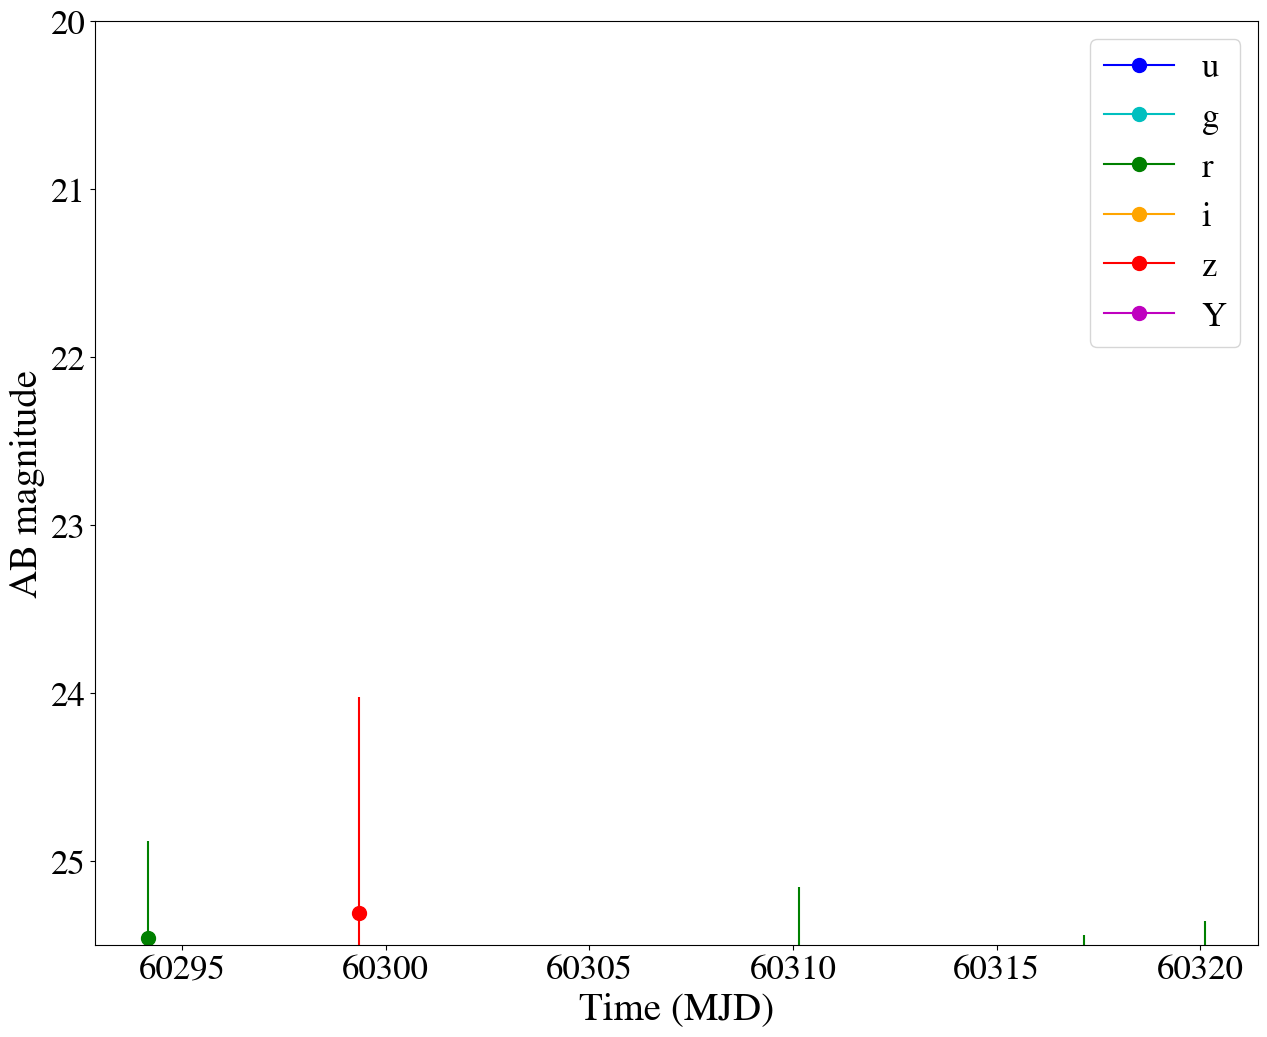

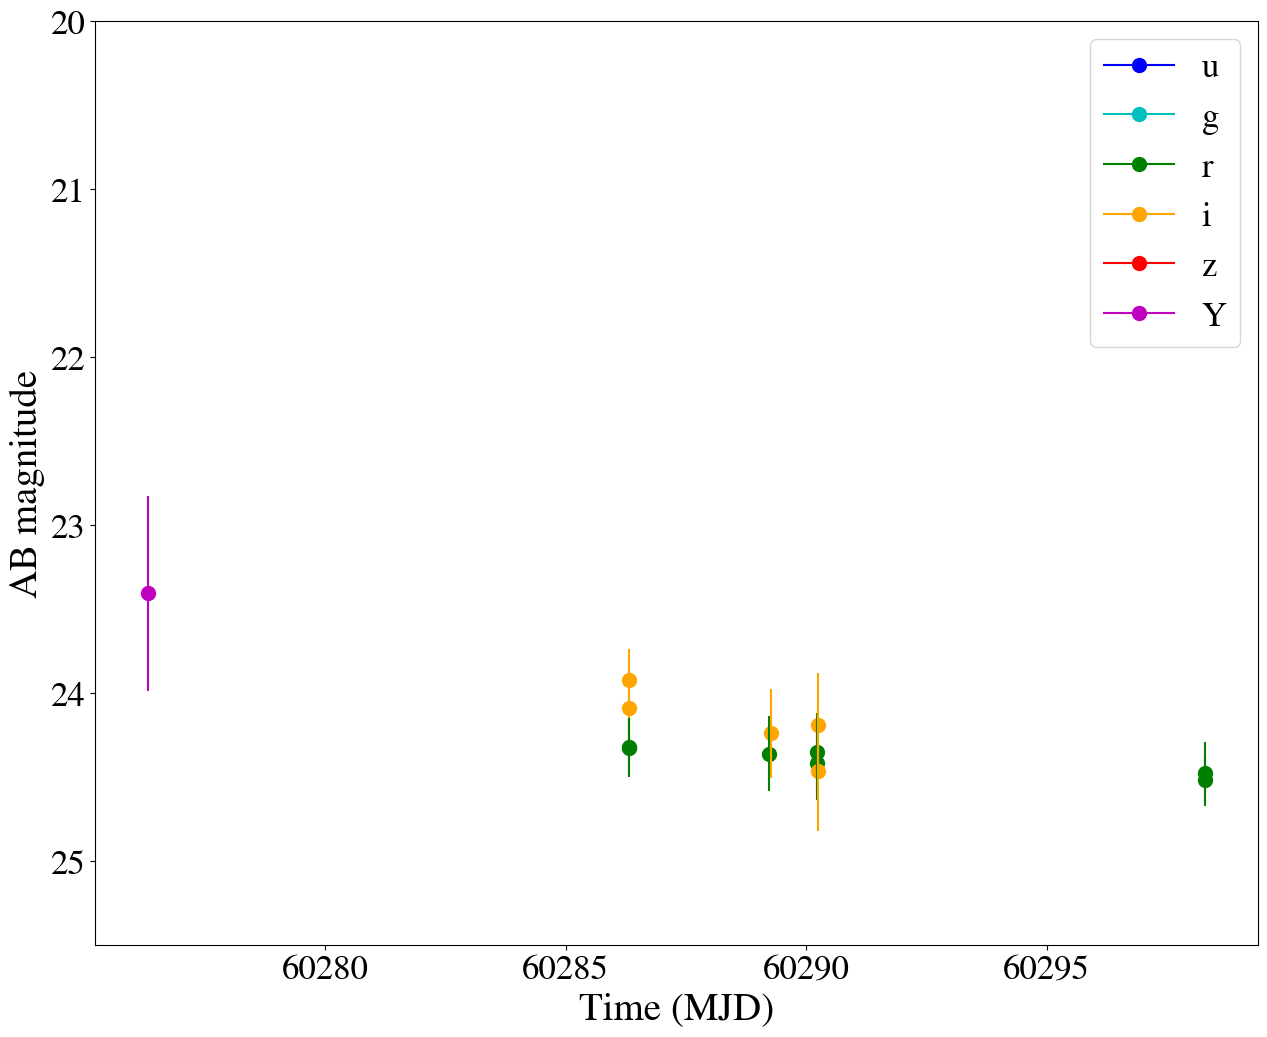

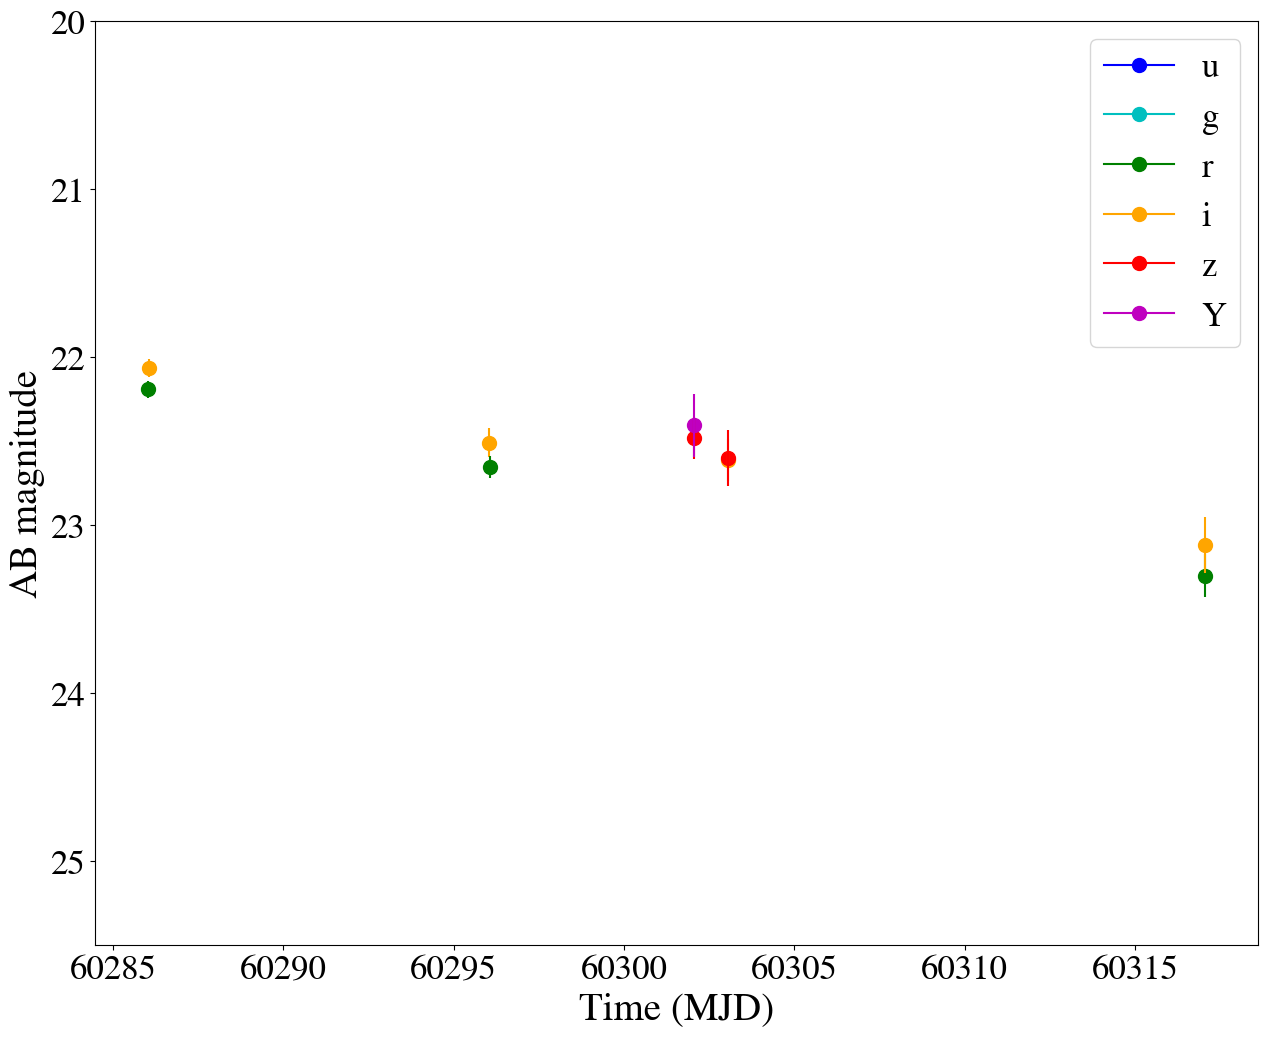

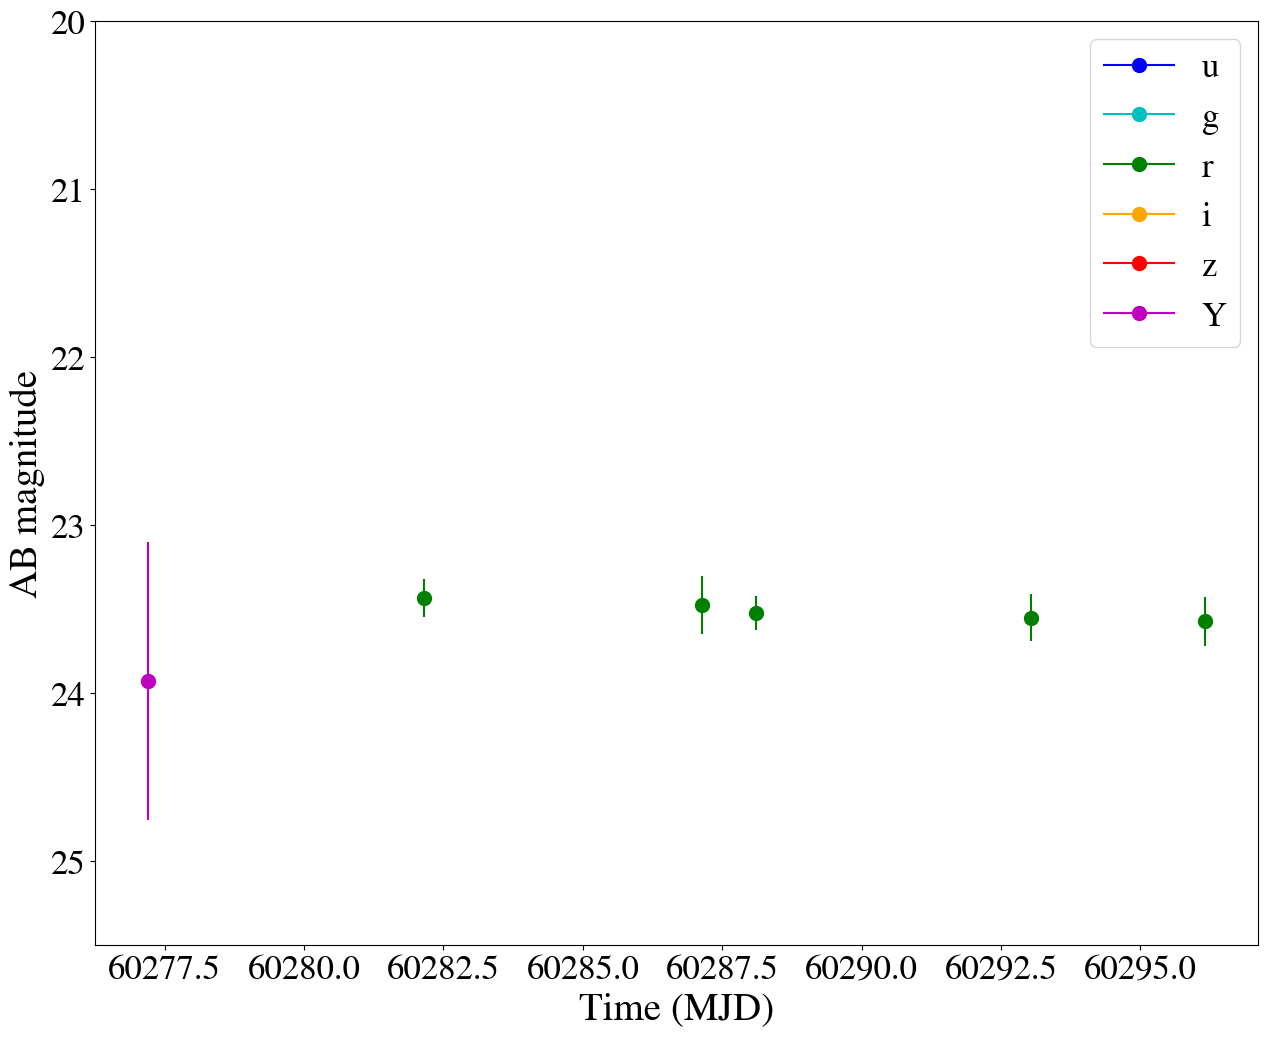

In [33]:
# plot all background events classified as orphans

colors = ['b', 'c', 'g', 'orange', 'r', 'm']
filterlist = ['u', 'g', 'r', 'i', 'z', 'Y']
filtercolors = {'u': 'b', 'g': 'c', 'r': 'g', 'i': 'orange', 'z': 'r', 'Y': 'm'}

plt.rcParams["figure.figsize"] = [15, 12]
plt.rcParams["font.size"] = 25

for i in alertId_elastorphan:
    
    times = np.array(df_elasticc_data[df_elasticc_data['alertId']==i]['time'])[0]
    mags = np.array(df_elasticc_data[df_elasticc_data['alertId']==i]['mags'])[0]
    filts = np.array(df_elasticc_data[df_elasticc_data['alertId']==i]['filt'])[0]
    errs = np.array(df_elasticc_data[df_elasticc_data['alertId']==i]['mags_err'])[0]
    
    for x, y, z, e in zip(times, mags, filts, errs):
        plt.scatter(x, y, c=filtercolors[z], s=100)
        plt.errorbar(x, y, e, c=filtercolors[z])
        

    plt.gca().invert_yaxis()
    plt.xlabel('Time (MJD)', fontsize=28)
    plt.ylabel('AB magnitude', fontsize=28)

    legend_elements_2 = []
    for filt in filterlist:
        fcolor = filtercolors[filt]
        legend_elements_2.append(Line2D([0], [0], marker='o', color=fcolor, label=filt,
                                      markerfacecolor=fcolor, markersize=10))
    plt.legend(handles=legend_elements_2)
    plt.ylim(25.5, 20.)
    #plt.xlim(62110, 62190)
    #plt.axhline(y=24.5, c='k', lw=0.5)
    plt.show()

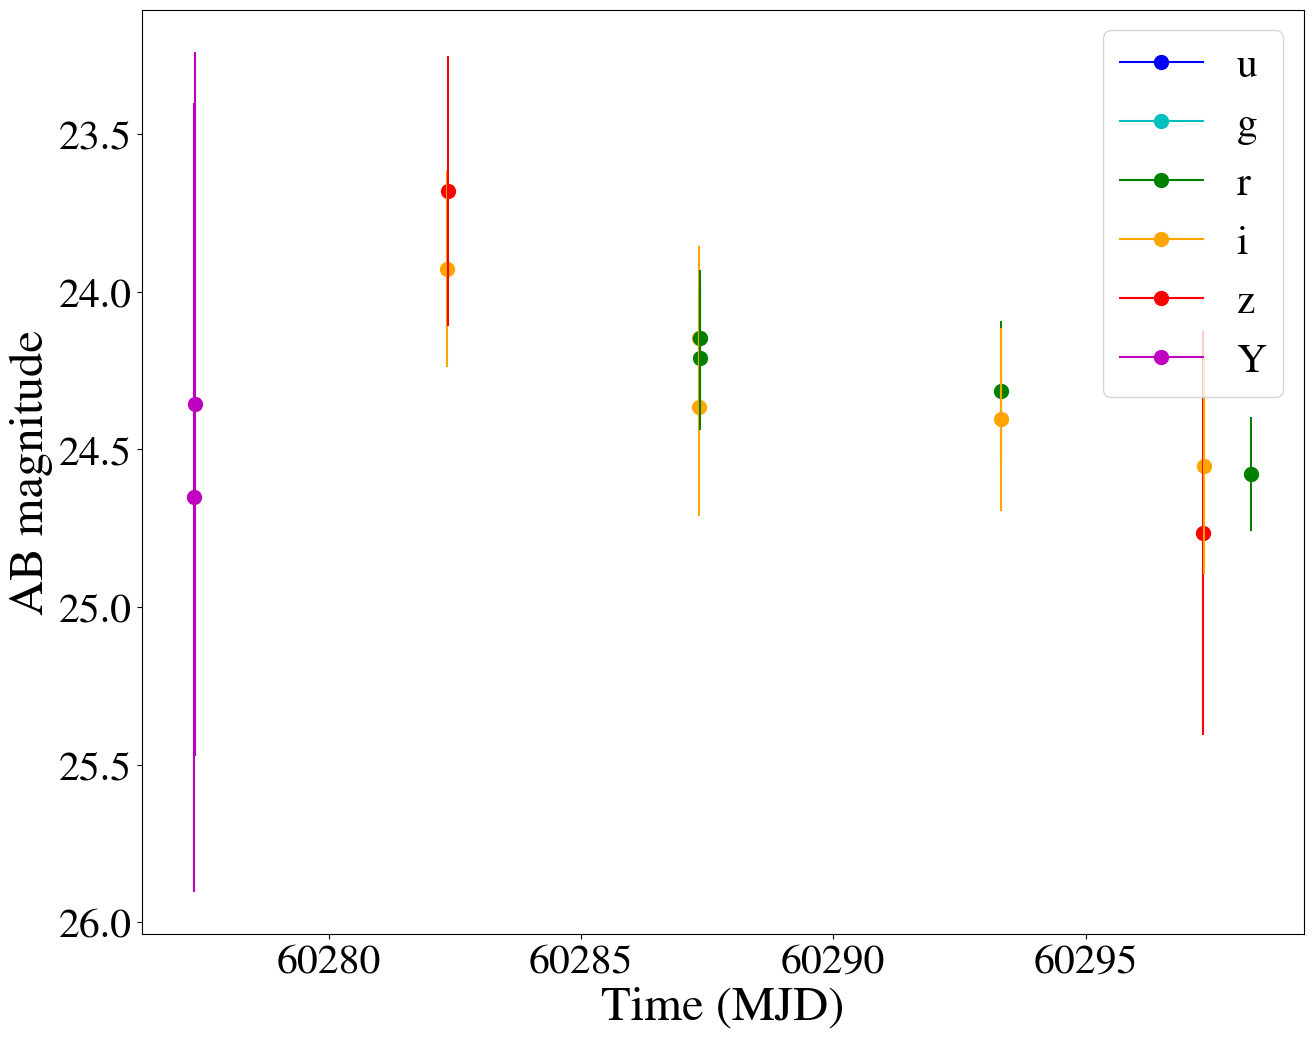

In [34]:
# choose one event to plot
i = alertId_elastorphan[1]

times = np.array(df_elasticc_data[df_elasticc_data['alertId']==i]['time'])[0]
mags = np.array(df_elasticc_data[df_elasticc_data['alertId']==i]['mags'])[0]
filts = np.array(df_elasticc_data[df_elasticc_data['alertId']==i]['filt'])[0]
errs = np.array(df_elasticc_data[df_elasticc_data['alertId']==i]['mags_err'])[0]


colors = ['b', 'c', 'g', 'orange', 'r', 'm']
filterlist = ['u', 'g', 'r', 'i', 'z', 'Y']
filtercolors = {'u': 'b', 'g': 'c', 'r': 'g', 'i': 'orange', 'z': 'r', 'Y': 'm'}

plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(15,12))

for x, y, z, e in zip(times, mags, filts, errs):
    plt.scatter(x, y, c=filtercolors[z], s=100)
    plt.errorbar(x, y, e, c=filtercolors[z])

plt.gca().invert_yaxis()
plt.xlabel('Time (MJD)', fontsize=35)
plt.ylabel('AB magnitude', fontsize=35)

legend_elements_2 = []
for filt in filterlist:
    fcolor = filtercolors[filt]
    legend_elements_2.append(Line2D([0], [0], marker='o', color=fcolor, label=filt,
                                  markerfacecolor=fcolor, markersize=10))
plt.legend(handles=legend_elements_2)
#plt.ylim(25.5, 20.)
#plt.xlim(62110, 62190)
#plt.axhline(y=24.5, c='k', lw=0.5)

#plt.savefig('../figures/elastorphan_SNII.pdf', format="pdf", bbox_inches="tight", transparent=True)

plt.show()